In [28]:
import pandas as pd
import numpy as np

In [29]:
PATH = './data'
TARGET = 'SalePrice'

In [30]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)

In [31]:
df = pd.read_csv(PATH + "/train.csv")

In [50]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.2, shuffle=True, random_state=42
)

train_ids = X_train["Id"]
test_ids = X_test["Id"]

print(f"X_train shape {X_train.shape}")
print(f"X_test shape {X_test.shape}")

X_train shape (1168, 80)
X_test shape (292, 80)


In [51]:
print(X_train.describe())

                Id   MSSubClass  LotFrontage        LotArea  OverallQual  OverallCond    YearBuilt  YearRemodAdd   MasVnrArea   BsmtFinSF1   BsmtFinSF2    BsmtUnfSF  TotalBsmtSF     1stFlrSF     2ndFlrSF  LowQualFinSF    GrLivArea  BsmtFullBath  BsmtHalfBath     FullBath     HalfBath  BedroomAbvGr  KitchenAbvGr  TotRmsAbvGrd   Fireplaces  GarageYrBlt   GarageCars   GarageArea   WoodDeckSF  OpenPorchSF  EnclosedPorch    3SsnPorch  ScreenPorch     PoolArea       MiscVal       MoSold       YrSold
count  1168.000000  1168.000000   951.000000    1168.000000  1168.000000  1168.000000  1168.000000   1168.000000  1162.000000  1168.000000  1168.000000  1168.000000  1168.000000  1168.000000  1168.000000   1168.000000  1168.000000   1168.000000   1168.000000  1168.000000  1168.000000   1168.000000   1168.000000   1168.000000  1168.000000  1104.000000  1168.000000  1168.000000  1168.000000  1168.000000    1168.000000  1168.000000  1168.000000  1168.000000   1168.000000  1168.000000  1168.000000
me

In [56]:
print(X_train.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1168 entries, 254 to 1126
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1168 non-null   int64  
 1   MSSubClass     1168 non-null   int64  
 2   MSZoning       1168 non-null   object 
 3   LotFrontage    951 non-null    float64
 4   LotArea        1168 non-null   int64  
 5   Street         1168 non-null   object 
 6   Alley          74 non-null     object 
 7   LotShape       1168 non-null   object 
 8   LandContour    1168 non-null   object 
 9   Utilities      1168 non-null   object 
 10  LotConfig      1168 non-null   object 
 11  LandSlope      1168 non-null   object 
 12  Neighborhood   1168 non-null   object 
 13  Condition1     1168 non-null   object 
 14  Condition2     1168 non-null   object 
 15  BldgType       1168 non-null   object 
 16  HouseStyle     1168 non-null   object 
 17  OverallQual    1168 non-null   int64  
 18  OverallCond

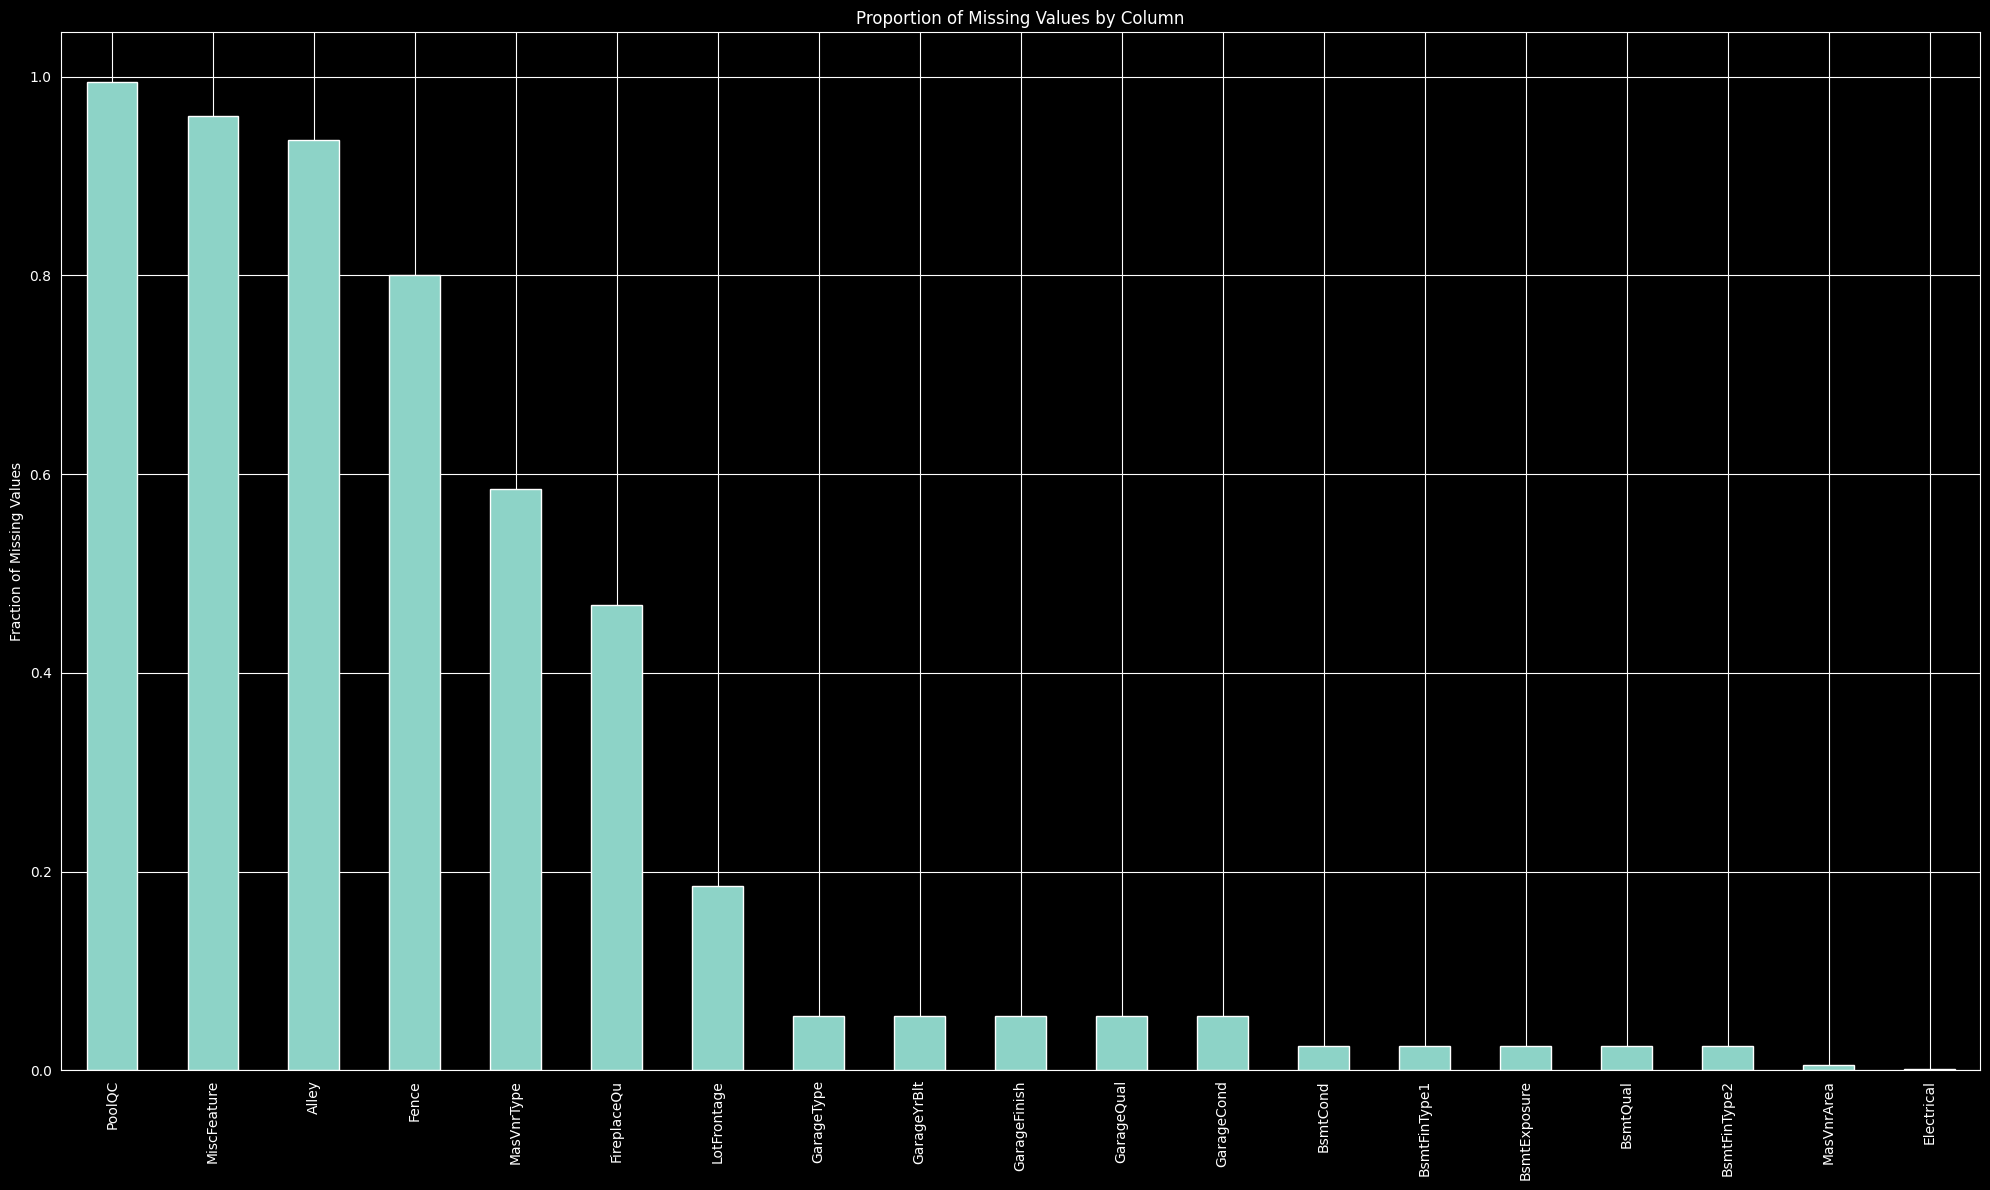

null_ratio (19):
PoolQC          0.994863
MiscFeature     0.960616
Alley           0.936644
Fence           0.800514
MasVnrType      0.584760
FireplaceQu     0.468322
LotFrontage     0.185788
GarageType      0.054795
GarageYrBlt     0.054795
GarageFinish    0.054795
GarageQual      0.054795
GarageCond      0.054795
BsmtCond        0.023973
BsmtFinType1    0.023973
BsmtExposure    0.023973
BsmtQual        0.023973
BsmtFinType2    0.023973
MasVnrArea      0.005137
Electrical      0.000856
dtype: float64


In [54]:
import matplotlib.pyplot as plt

null_ratio = X_train.isna().sum() / X_train.shape[0]
null_ratio = null_ratio[null_ratio > 0].sort_values(ascending=False)

plt.figure(figsize=(20, 12))
null_ratio.plot(kind='bar')
plt.title('Proportion of Missing Values by Column')
plt.ylabel('Fraction of Missing Values')
plt.tight_layout()
plt.show()

print(f"null_ratio ({len(null_ratio)}):\n{null_ratio}")

In [69]:
import matplotlib.pyplot as plt

print(df.select_dtypes(include=['object']).nunique())

# plt.title("Number of Unique Categories per Feature")
# plt.ylabel("Count of Categories")
# plt.show()

MSZoning          5
Street            2
Alley             2
LotShape          4
LandContour       4
Utilities         2
LotConfig         5
LandSlope         3
Neighborhood     25
Condition1        9
Condition2        8
BldgType          5
HouseStyle        8
RoofStyle         6
RoofMatl          8
Exterior1st      15
Exterior2nd      16
MasVnrType        3
ExterQual         4
ExterCond         5
Foundation        6
BsmtQual          4
BsmtCond          4
BsmtExposure      4
BsmtFinType1      6
BsmtFinType2      6
Heating           6
HeatingQC         5
CentralAir        2
Electrical        5
KitchenQual       4
Functional        7
FireplaceQu       5
GarageType        6
GarageFinish      3
GarageQual        5
GarageCond        5
PavedDrive        3
PoolQC            3
Fence             4
MiscFeature       4
SaleType          9
SaleCondition     6
dtype: int64


In [34]:
print(X_train['PoolQC'].value_counts(dropna=False))

PoolQC
NaN    1162
Fa        2
Ex        2
Gd        2
Name: count, dtype: int64


In [35]:
print(X_train['MasVnrType'].value_counts(dropna=False))

MasVnrType
NaN        683
BrkFace    366
Stone      106
BrkCmn      13
Name: count, dtype: int64


In [36]:
print(X_train['LotFrontage'].value_counts(dropna=False))

LotFrontage
NaN      217
60.0     112
70.0      57
80.0      54
50.0      47
75.0      42
65.0      35
85.0      32
78.0      21
90.0      19
21.0      17
72.0      15
63.0      15
68.0      14
24.0      14
74.0      13
73.0      13
79.0      13
64.0      13
55.0      12
43.0      12
40.0      12
67.0      11
82.0      11
100.0     11
51.0      11
59.0      10
71.0      10
52.0       9
69.0       9
57.0       9
88.0       8
35.0       8
53.0       7
44.0       7
86.0       7
92.0       7
84.0       7
93.0       7
76.0       7
66.0       7
91.0       6
107.0      6
95.0       6
98.0       6
58.0       6
77.0       6
81.0       6
30.0       6
61.0       6
62.0       6
105.0      6
34.0       6
120.0      6
41.0       5
83.0       5
87.0       5
36.0       5
96.0       5
110.0      5
89.0       5
94.0       4
48.0       4
32.0       4
49.0       4
47.0       4
102.0      4
54.0       4
42.0       4
56.0       4
108.0      3
103.0      3
37.0       3
99.0       3
122.0      2
45.0       2


In [37]:
print(X_train['GarageType'].value_counts(dropna=False))

GarageType
Attchd     693
Detchd     308
BuiltIn     74
NaN         64
Basment     16
CarPort      7
2Types       6
Name: count, dtype: int64


In [57]:
print(X_train['GarageYrBlt'].value_counts(dropna=False))

GarageYrBlt
NaN       64
2005.0    52
2006.0    45
2004.0    45
2003.0    40
2007.0    40
1998.0    27
1977.0    25
1999.0    24
2000.0    23
2002.0    22
1976.0    21
2008.0    21
1950.0    20
1968.0    20
2009.0    19
1965.0    18
1970.0    18
2001.0    18
1962.0    17
1960.0    17
1958.0    17
1996.0    17
1957.0    17
1966.0    17
1954.0    15
1997.0    15
1993.0    15
1978.0    14
1979.0    14
1964.0    14
1974.0    14
1995.0    14
1990.0    13
1994.0    13
1963.0    13
1959.0    13
1971.0    12
1967.0    12
1972.0    12
1956.0    11
1969.0    11
1953.0    11
1980.0    11
1961.0    11
1988.0    11
1955.0    11
1973.0    11
1981.0     9
1920.0     9
1941.0     9
1925.0     9
1992.0     9
1989.0     9
1987.0     9
1939.0     8
1948.0     8
1984.0     8
1985.0     7
1930.0     7
1940.0     7
1975.0     7
1949.0     6
1991.0     6
1983.0     6
1926.0     5
1916.0     5
1936.0     4
1945.0     4
1951.0     4
1986.0     4
1931.0     4
1923.0     3
2010.0     3
1910.0     3
1932.0     3


In [39]:
print(X_train['GarageFinish'].value_counts(dropna=False))

GarageFinish
Unf    480
RFn    339
Fin    285
NaN     64
Name: count, dtype: int64


In [45]:
print(X_train['MasVnrArea'].value_counts(dropna=False))

MasVnrArea
0.0       674
108.0       7
180.0       7
16.0        6
106.0       6
200.0       6
NaN         6
120.0       6
340.0       6
72.0        6
84.0        5
320.0       5
360.0       5
132.0       5
80.0        5
220.0       4
288.0       4
183.0       4
160.0       4
178.0       4
196.0       4
40.0        4
170.0       4
116.0       3
300.0       3
256.0       3
456.0       3
268.0       3
90.0        3
210.0       3
168.0       3
110.0       3
130.0       3
186.0       3
272.0       3
240.0       3
174.0       3
42.0        3
85.0        3
246.0       3
82.0        3
44.0        3
100.0       3
216.0       3
166.0       3
350.0       3
104.0       3
99.0        3
105.0       2
304.0       2
147.0       2
233.0       2
30.0        2
425.0       2
424.0       2
226.0       2
236.0       2
245.0       2
302.0       2
75.0        2
125.0       2
480.0       2
232.0       2
243.0       2
281.0       2
76.0        2
54.0        2
285.0       2
260.0       2
158.0       2
270.0    

In [47]:
print(X_train['Electrical'].value_counts(dropna=False))

Electrical
SBrkr    1071
FuseA      69
FuseF      24
FuseP       3
NaN         1
Name: count, dtype: int64
